# Understand size and distribution of contrail-sensitive regions

## 1. Download gridded CoCiP output from contrails.org
- Contrails.org provide global gridded CoCiP outputs via their API (https://apidocs.contrails.org/notebooks/research_api.html)
- Intro to gridded CoCiP: https://py.contrails.org/notebooks/CoCiPGrid.html
- Original publication: https://gmd.copernicus.org/articles/18/253/2025/
- Hourly coverage looks as follows, the other files were not available despite repeated API requests
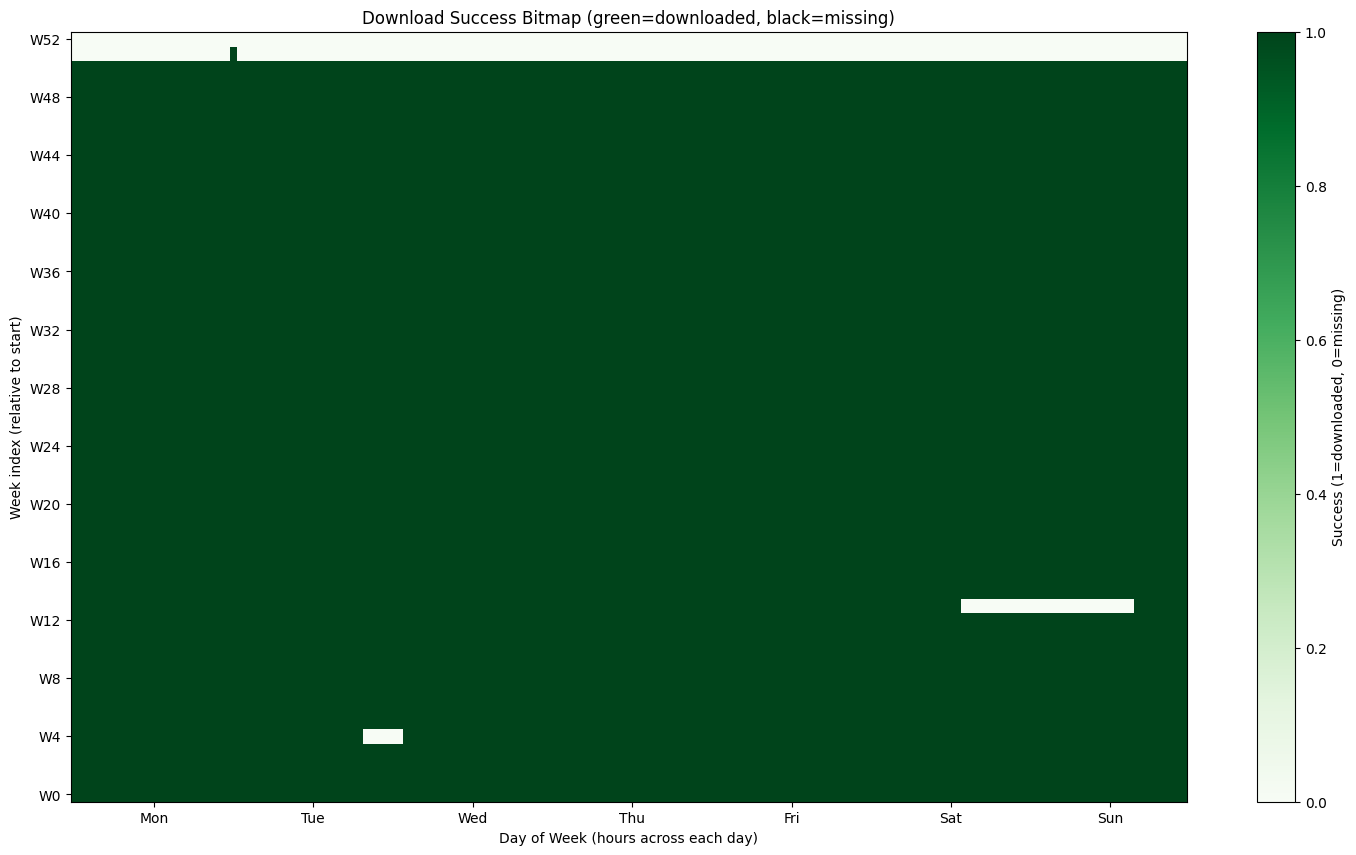

## 1. Download gridded CoCiP from contrails.org

In [ ]:
from datetime import datetime, timedelta
from tqdm import tqdm
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
import requests
import requests  # don’t forget to import
from google.colab import userdata
import requests

API_KEY = userdata.get('CONTRAILS_API_KEY')
URL = "https://api.contrails.org"
HEADERS = {"x-api-key": API_KEY}

START_DATE = "2024-01-09"
END_DATE   = "2024-12-31"  # inclusive
OUTDIR = "/content/drive/MyDrive/GriddedCoCip/contrails.org"

os.makedirs(OUTDIR, exist_ok=True)

start_dt = datetime.fromisoformat(START_DATE)
end_dt   = datetime.fromisoformat(END_DATE)

def download_file(dt):
    time_str = dt.strftime("%Y-%m-%dT%H")
    fname = dt.strftime("%Y%m%dT%H") + ".nc"
    outpath = os.path.join(OUTDIR, fname)

    if os.path.exists(outpath):
        return f"Skipped {time_str} (already exists)"

    params = {
        "time": time_str,
        "bbox": "-180,-89,180,89",  # global
        "engine_efficiency": 0.32,
        "aircraft_type": "A320"
    }

    try:
        r = requests.get(f"{URL}/v0/grid/cocip", params=params,
                         headers=HEADERS, timeout=120)
        if r.status_code == 200 and "netcdf" in r.headers.get("content-type", "").lower():
            with open(outpath, "wb") as f:
                f.write(r.content)
            return f"Downloaded {time_str}"
        else:
            return f"Failed {time_str}: {r.status_code} {r.reason}"
    except Exception as e:
        return f"Error {time_str}: {e}"

# Build list of datetimes
all_dts = []
curr_dt = start_dt
while curr_dt <= end_dt:
    for h in range(24):
        all_dts.append(curr_dt + timedelta(hours=h))
    curr_dt += timedelta(days=1)

# Run in parallel (tune workers to avoid server overload)
with ThreadPoolExecutor(max_workers=5) as executor:
    futures = [executor.submit(download_file, dt) for dt in all_dts]
    for future in as_completed(futures):
        print(future.result())

Streaming output truncated to the last 5000 lines.
Skipped 2024-06-06T20 (already exists)
Skipped 2024-06-06T21 (already exists)
Skipped 2024-06-06T22 (already exists)
Skipped 2024-06-06T23 (already exists)
Skipped 2024-06-07T00 (already exists)
Skipped 2024-06-07T01 (already exists)
Skipped 2024-06-07T02 (already exists)
Skipped 2024-06-07T03 (already exists)
Skipped 2024-06-07T04 (already exists)
Skipped 2024-06-07T05 (already exists)
Skipped 2024-06-07T06 (already exists)
Skipped 2024-06-07T07 (already exists)
Skipped 2024-06-07T08 (already exists)
Skipped 2024-06-07T09 (already exists)
Skipped 2024-06-07T10 (already exists)
Skipped 2024-06-07T11 (already exists)
Skipped 2024-06-07T12 (already exists)
Skipped 2024-06-07T13 (already exists)
Skipped 2024-06-07T14 (already exists)
Skipped 2024-06-07T15 (already exists)
Skipped 2024-06-07T16 (already exists)
Skipped 2024-06-07T17 (already exists)
Skipped 2024-06-07T18 (already exists)
Skipped 2024-06-07T19 (already exists)
Skipped 2024-

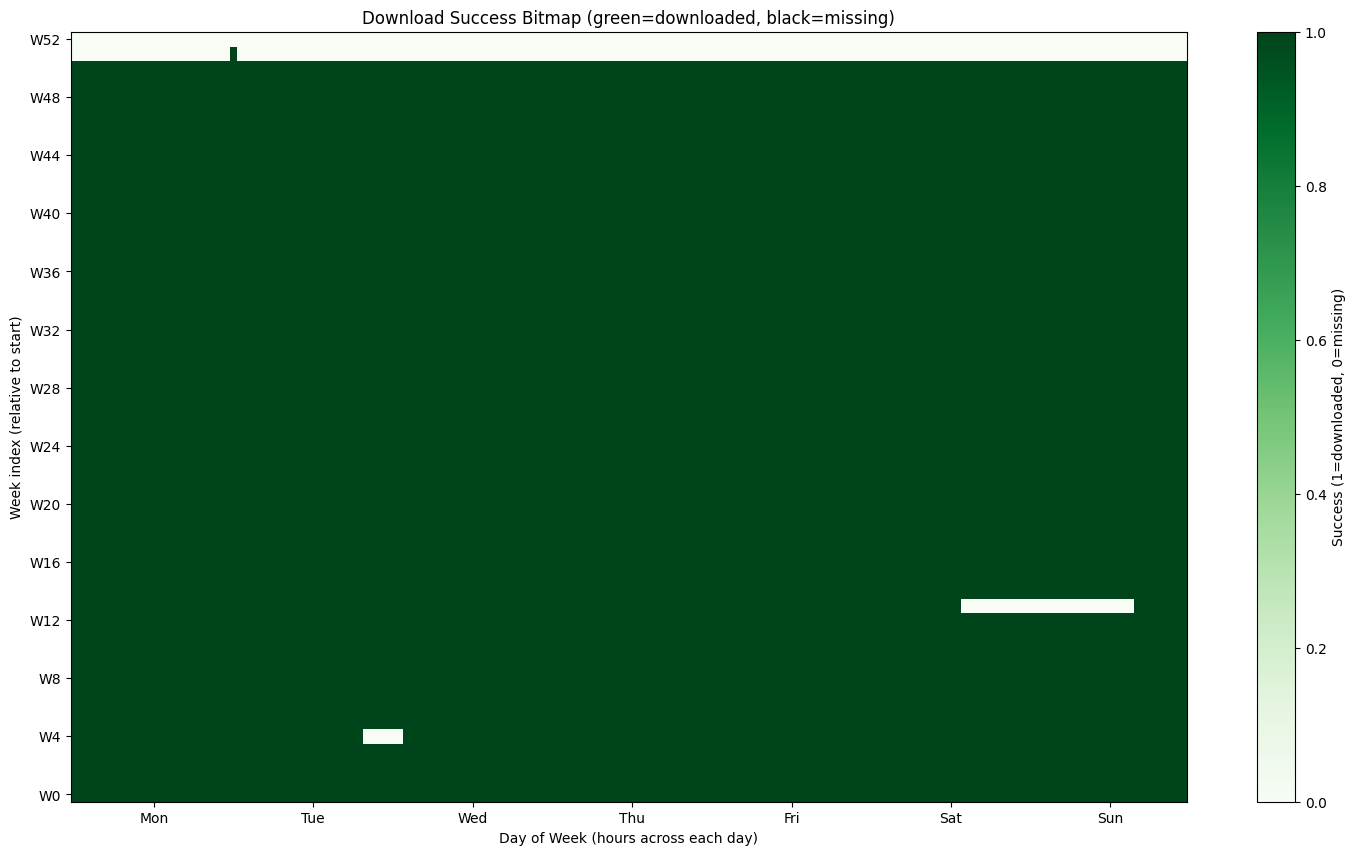

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import calendar
import re
import os
from datetime import datetime, timedelta

START_DATE = "2024-01-09"
END_DATE   = "2024-12-31"  # inclusive
OUTDIR = "/content/drive/MyDrive/GriddedCoCip/contrails.org"
start_dt = datetime.fromisoformat(START_DATE)
end_dt   = datetime.fromisoformat(END_DATE)

# Collect which hours exist as files
downloaded = set()
pattern = re.compile(r"(\d{8}T\d{2})\.nc")

for fname in os.listdir(OUTDIR):
    m = pattern.match(fname)
    if m:
        dt = datetime.strptime(m.group(1), "%Y%m%dT%H")
        downloaded.add(dt)

# Compute week span properly
start_iso = start_dt.isocalendar()
end_iso   = end_dt.isocalendar()

# Total number of weeks between start and end (inclusive)
total_days = (end_dt - start_dt).days + 1
weeks = (total_days // 7) + 2   # +2 margin for partial weeks

bitmap = np.zeros((weeks, 7*24), dtype=int)

# Fill bitmap
curr_dt = start_dt
while curr_dt <= end_dt:
    iso_year, iso_week, iso_day = curr_dt.isocalendar()

    # Compute relative week index from start date
    week_index = ((curr_dt - start_dt).days) // 7
    day_index  = (iso_day - 1) * 24 + curr_dt.hour

    if week_index < weeks:
        bitmap[week_index, day_index] = 1 if curr_dt in downloaded else 0

    curr_dt += timedelta(hours=1)

# Plot
plt.figure(figsize=(18, 10))
plt.imshow(bitmap, aspect='auto', cmap='Greens', origin='lower')

# Label weeks and days
yticks = range(0, weeks, 4)  # every 4th week
plt.yticks(yticks, [f"W{w}" for w in yticks])
plt.xticks([i*24+12 for i in range(7)], list(calendar.day_abbr))

plt.xlabel("Day of Week (hours across each day)")
plt.ylabel("Week index (relative to start)")
plt.title("Download Success Bitmap (green=downloaded, black=missing)")
plt.colorbar(label="Success (1=downloaded, 0=missing)")
plt.show()


# 2. Visualise average contrail sensitivity of airspace across the year

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_map(ds, var="ef_per_m", title="Map", savepath=None):

    # take one timestep (e.g. index 10)
    data_2d = ds[var].sel(flight_level=350).squeeze()

    # replace zeros with NaN for clarity
    data_np = data_2d.where(data_2d != 0).values

    lon = data_2d.longitude.values
    lat = data_2d.latitude.values

    # set up map
    fig, ax = plt.subplots(
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(20, 12)
    )
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":")
    ax.add_feature(cfeature.LAND, facecolor="white")
    ax.add_feature(cfeature.OCEAN, facecolor="white")
    ax.set_global()

    # plot data
    im = ax.imshow(
        data_np.T,   # transpose to match lon/lat
        origin="lower",
        cmap="coolwarm",
        transform=ccrs.PlateCarree(),
        extent=[lon.min(), lon.max(), lat.min(), lat.max()],
    )

    # colorbar
    cbar = plt.colorbar(im, ax=ax, orientation="vertical", shrink=0.4)
    cbar.set_label("Energy forcing (J/m)")

    ax.set_title(f"Contrail climate impact")
    plt.show()


def plot_outputs(file_dict, var="ef_per_m", outdir="maps"):
    """
    Loop over NetCDF outputs and plot maps.

    Parameters
    ----------
    file_dict : dict
        Dictionary of label → file paths (e.g., {(month, hour): path})
    var : str
        Variable name to plot (default: ef_per_m)
    outdir : str
        Directory where plots are saved
    """
    os.makedirs(outdir, exist_ok=True)
    for key, filepath in file_dict.items():
        try:
            ds = xr.open_dataset(filepath)
            if isinstance(key, tuple):  # monthly/hourly
                month, hour = key
                title = f"Contrail Climate Impact | Month={month:02d}, Hour={hour:02d}"
                fname = f"map_month{month:02d}_hour{hour:02d}.png"
            else:  # monthly only
                month = key
                title = f"Contrail Climate Impact | Month={month:02d}"
                fname = f"map_month{month:02d}.png"

            savepath = os.path.join(outdir, fname)
            plot_map(ds, var=var, title=title, savepath=savepath)
            ds.close()
            print(f"✅ Saved {savepath}")
        except Exception as e:
            print(f"⚠️ Error plotting {filepath}: {e}")


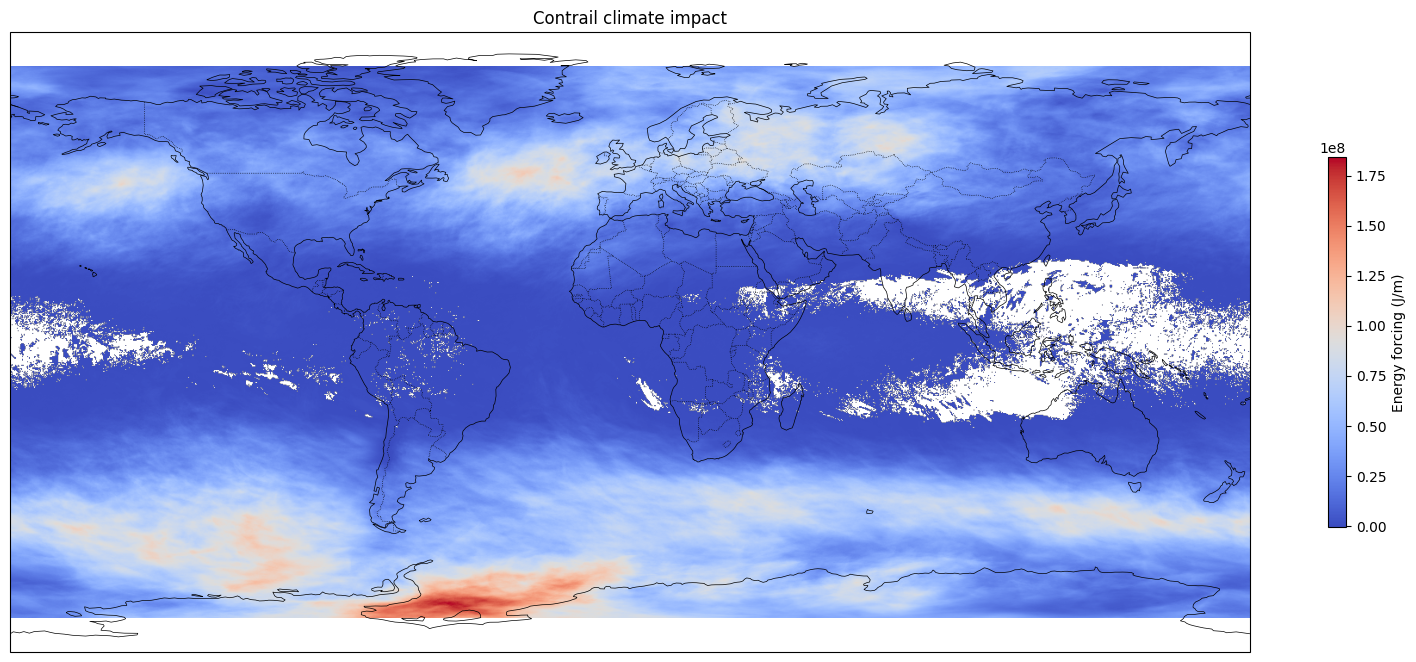

In [ ]:
import xarray as xr
import os

# path where you saved the files
indir = "/content/drive/MyDrive/GriddedCoCip/contrails.org/analysis/"

# open one file (example)
fname = "annual_average.nc"
ds = xr.open_dataset(os.path.join(indir, fname))


title = f"Contrail Climate Impact 2019"
fname = f"map_year.png"

plot_map(ds, var="ef_per_m", title=title, savepath="")

## 2. Analyse ISSR distribution

- Take the gridded CoCiP output for every hour
- We take an Airbus A320 as representative aircraft with an engine efficiency of 0.32 and download the grid for the whole globe
- Identify connected regions where the energy forcing in J/m in a given hour is above a given threshold
- This threshold comes from https://gmd.copernicus.org/articles/18/253/2025/
- The grid-based CoCiP defines regions with strongly warming contrails based on the 80th percentile (5×108 J m−1) and the 95th percentile (1.5×109 J m−1) of EFcontrail per flight distance flown, both of which were derived from a 2019 global contrail simulation using the trajectory-based CoCiP (Teoh et al., 2024a).
- We therefore use 5e8 J/m as threshold
- These regions need to lie within the bounding box lon = (-90.0, 40.0) and lat = (30.0, 80.0)
- If they intersect with the bounding box - discard them (this potentially disqualifies regions that stretch into the arctic)
- Compute key stats for every identified region such as mean latitude, longitude, altitude, width, forcing etc. 
- Save all stats to giant list containing the identified regions for all hours 

### Weaknesses of this analysis
- The intersection condition implies that we potentially miss out on very big ISSRs that consistently go to the North pole or have very high longitudinal elongation
- We do not track the evolution of ISSRs over time - in consecutive hours, we consider the same ISSR but don't actually track which ISSRs are the same  - so this is really an analysis about annual average properties of ISSRs rather than a study of how individual ISSRs evolve

# 1. Download Gridded CoCiP outputs

In [ ]:
from datetime import datetime, timedelta
from tqdm import tqdm
import os
from concurrent.futures import ThreadPoolExecutor, as_completed
import requests

API_KEY = ""
URL = "https://api.contrails.org"
HEADERS = {"x-api-key": API_KEY}

START_DATE = "2024-01-09"
END_DATE   = "2024-12-31"  # inclusive
OUTDIR = "data/sac"

os.makedirs(OUTDIR, exist_ok=True)

start_dt = datetime.fromisoformat(START_DATE)
end_dt   = datetime.fromisoformat(END_DATE)

def download_file(dt):
    time_str = dt.strftime("%Y-%m-%dT%H")
    fname = dt.strftime("%Y%m%dT%H") + ".nc"
    outpath = os.path.join(OUTDIR, fname)

    if os.path.exists(outpath):
        return f"Skipped {time_str} (already exists)"

    params = {
        "time": time_str,
        "bbox": "-180,-89,180,89",  # global
        "engine_efficiency": 0.32,
        "aircraft_type": "A320", 
        "format": "geojson"
    }

    try:
        r = requests.get(f"{URL}/v0/grid/sac", params=params,
                         headers=HEADERS, timeout=120)
                
        print(f"HTTP Response Code: {r.status_code} {r.reason}")
        print(f"Response content-type: {r.headers['content-type']}")

    except Exception as e:
        return f"Error {time_str}: {e}"

# Build list of datetimes
all_dts = []
curr_dt = start_dt
while curr_dt <= end_dt:
    for h in range(24):
        all_dts.append(curr_dt + timedelta(hours=h))
    curr_dt += timedelta(days=1)

# Run in parallel (tune workers to avoid server overload)
with ThreadPoolExecutor(max_workers=5) as executor:
    futures = [executor.submit(download_file, dt) for dt in all_dts]
    for future in as_completed(futures):
        print(future.result())

## 2. Analyse contrail-sensitive regions

In [ ]:
import numpy as np
import pandas as pd
import shapely
import regionmask
from scipy import ndimage
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import glob
import os

# ---------------------------------------
# CONFIGURATION
# ---------------------------------------
input_pattern = "2024*.nc"
output_file = "contrail_region_details_2024.csv"
n_workers = os.cpu_count() - 2  # use all but two cores

# European airspace bounding box - this is a very generous bounding box that also includes parts of North America
bbox = shapely.geometry.box(-90.0, 30.0, 40.0, 80.0)
mask_reg = regionmask.Regions([bbox])

R = 6371.0  # Earth radius in km
big_hit_region_threshold = 5 * 1e8 # J/m

# ---------------------------------------
# HELPER FUNCTION
# ---------------------------------------
def process_file(filepath):
    """Process one hourly CoCiP file and return region-level metrics."""
    try:
        ds = xr.open_dataset(filepath)
        ds_hr = ds.isel(time=0)
        ef = ds_hr["ef_per_m"].transpose("latitude", "longitude", "flight_level")
        lat = ef.latitude.values
        lon = ef.longitude.values
        lev = ef.flight_level.values
        time = pd.to_datetime(str(ds.time.values[0]))

        # European airspace mask
        mask2d = mask_reg.mask(lon, lat)
        ecac_mask_2d = np.isfinite(mask2d.values)
        ecac_mask_3d = np.repeat(ecac_mask_2d[:, :, None], ef.shape[2], axis=2)

        # Area grid

        # Ensure that lat-long grid is regular
        assert(np.diff(lat).min() == np.diff(lat).max())
        assert(np.diff(lon).min() == np.diff(lon).max())

        # Get grid spacing in radians
        dlat = np.deg2rad(np.abs(np.diff(lat)).mean())
        dlon = np.deg2rad(np.abs(np.diff(lon)).mean())
        lat_rad = np.deg2rad(lat)

        # Approximate latitude dependent area of a single cell
        cell_area_lat = (R**2) * dlat * dlon * np.cos(lat_rad)

        # Create 3D array that contain grid cell array
        area_2d = np.repeat(cell_area_lat[:, None], len(lon), axis=1)
        area_3d = np.repeat(area_2d[:, :, None], ef.shape[2], axis=2)

        # Flight level heights (m)
        # Approximate that 1 feet = 0.3048 (even though this is barometric altitude)
        fl_ft = lev * 100.0
        fl_m = fl_ft * 0.3048
        lev_heights_m = fl_m

        # Positive forcing inside 
        pos_mask_3d = (ef.values > big_hit_region_threshold) & ecac_mask_3d
        pos_mask_3d = np.where(np.isnan(ef.values), False, pos_mask_3d)
                

        # Enforce longitudinal periodicity
        structure = ndimage.generate_binary_structure(rank=3, connectivity=1)
        
        # Standard labeling
        # labeled_3d is a 3D array where regions below the threshold are 0 and all connected regions
        # get the same numerical label, n_label is the number of labels = number of ISSRs
        labeled_3d, n_labels = ndimage.label(pos_mask_3d, structure=structure)
        if n_labels == 0:
            return pd.DataFrame([])

        # Discard regions that touch the boundary
        valid_mask = ecac_mask_3d.astype(bool)

        # boundary mask: edges
        boundary = np.zeros_like(valid_mask, dtype=bool)
        boundary[0, :, :]  = True
        boundary[-1, :, :] = True
        boundary[:, 0, :]  = True
        boundary[:, -1, :] = True
        boundary[:, :, 0]  = True
        boundary[:, :, -1] = True

        # Add internal holes (adjacent to invalids) to boundary mask
        eroded = ndimage.binary_erosion(valid_mask, structure=structure, border_value=0)
        boundary |= valid_mask & ~eroded

        # Get a list of labels that touch the boundary to discard them
        boundary_labels = np.unique(labeled_3d[boundary])
        boundary_labels = boundary_labels[boundary_labels > 0]

        # Keep only interior labels
        all_labels = np.unique(labeled_3d)
        all_labels = all_labels[all_labels > 0]
        interior_labels = np.setdiff1d(all_labels, boundary_labels)

        # Restrict the labeling to interior regions
        mask_interior = np.isin(labeled_3d, interior_labels)
        labeled_3d[~mask_interior] = 0
        n_labels = len(interior_labels)
            
        indices = np.arange(1, n_labels + 1)
        ef_vals = np.where(pos_mask_3d, ef.values, np.nan)

        # Prepare coordinate grids
        LAT2D, LON2D = np.meshgrid(lat, lon, indexing="ij")
        LAT3D = np.repeat(LAT2D[:, :, None], ef.shape[2], axis=2)
        LON3D = np.repeat(LON2D[:, :, None], ef.shape[2], axis=2)

        # Compute per-region stats
        region_records = []
        for lab in indices:
            mask = (labeled_3d == lab)
            if not np.any(mask):
                continue

            weights = area_3d[mask]
            lat_pts = LAT3D[mask]
            lon_pts = LON3D[mask]


            # Lat/Lon centroid (area-weighted)
            weights = area_3d[mask]
            lat_mean = np.average(LAT3D[mask], weights=weights)
            
            # Circular mean of longitude (in radians)
            # The key concern here is to ensure that this is invariant
            # under the choice of longitudinal coordinate system
            lon_rad = np.deg2rad(lon_pts)
            lon_mean_rad = np.arctan2(
                np.average(np.sin(lon_rad), weights=weights),
                np.average(np.cos(lon_rad), weights=weights)
            )
            lon_mean = np.degrees(lon_mean_rad)
            
            
            # Lateral extent
            # Area grid and grid spacing
            dlat = np.abs(np.diff(lat)).mean()          # degrees
            dlon = np.abs(np.diff(lon)).mean()          # degrees
            
            # Forcing
            ef_std  = np.nanstd (ef_vals[mask])
            ef_mean = np.nanmean(ef_vals[mask])
            ef_max  = np.nanmax (ef_vals[mask])

            # Flight level (mean) and thickness
            levels_present = np.any(np.any(mask, axis=0), axis=0)
            lev_ids = np.where(levels_present)[0]
            if len(lev_ids) == 0:
                continue
            
            dz = np.mean(np.diff(lev_heights_m)) if len(lev_heights_m) > 1 else 0
            zmin = lev_heights_m[lev_ids].min()
            zmax = lev_heights_m[lev_ids].max()

            # Compute thickness of flight level
            thickness_m   = zmax - zmin + dz
            thickness_std = np.std(lev_heights_m[lev_ids])
            mean_FL = np.mean(lev[lev_ids])

            
            # Area (km²)
            area_km2 = np.nansum(area_3d[mask])
            # Volume (km^3)
            volume_km3 = area_km2 * thickness_m / 1000

            # Save region record
            region_records.append({
                "time":          time,
                "file":          os.path.basename(filepath),
                "region_id":     lab,
                "area_km2":      area_km2,
                "pt in mask":    mask.sum(),
                "vol_km3":       volume_km3,
                "thickness_m":   thickness_m,
                "std_thickness": thickness_std,
                "mean_FL":       mean_FL,
                "mean_lat":      lat_mean,
                "mean_lon":      lon_mean,
                "mean_forcing":  ef_mean,
                "max_forcing":   ef_max,
                "std_forcing":   ef_std,
            })

        ds.close()
        return pd.DataFrame(region_records)

    except Exception as e:
        print(f"⚠️ Error processing {filepath}: {e}")
        return pd.DataFrame([])
    
import traceback

# ---------------------------------------
# MAIN EXECUTION BLOCK 
# This execution block has some features for restarting a run if it fails
# It also performs regular saves
# Running this with 30 cores takes around 24h
# ---------------------------------------
def main():
    files = sorted(glob.glob(input_pattern))
    print(f"Found {len(files)} hourly files.")
    if not files:
        print("⚠️ No files matched the pattern.")
        return

    # --- optional: resume capability ---
    if os.path.exists(output_file):
        existing = pd.read_csv(output_file)
        done_files = set(existing["file"].unique())
        files = [f for f in files if os.path.basename(f) not in done_files]
        all_dfs = [existing]
        print(f"Resuming from previous run: {len(done_files)} already processed.")
    else:
        all_dfs = []
        done_files = set()

    n_total = len(files)
    if n_total == 0:
        print("✅ All files already processed.")
        return

    # --- partial save configuration ---
    save_every = 20  # save every N files
    temp_file = output_file.replace(".csv", "_partial.csv")

    try:
        with ProcessPoolExecutor(max_workers=n_workers) as executor:
            futures = {executor.submit(process_file, f): f for f in files}
            processed = 0

            for fut in tqdm(as_completed(futures), total=n_total, desc="Processing files"):
                filepath = futures[fut]
                try:
                    df_part = fut.result()
                    if not df_part.empty:
                        all_dfs.append(df_part)
                        done_files.add(os.path.basename(filepath))
                except Exception as e:
                    print(f"⚠️ Failure in {filepath}: {e}")
                    traceback.print_exc(limit=1)
                    continue

                processed += 1
                # --- periodic save ---
                if processed % save_every == 0:
                    try:
                        df_temp = pd.concat(all_dfs, ignore_index=True)
                        df_temp.to_csv(temp_file, index=False)
                        print(f"💾 Saved interim results ({processed}/{n_total}) to {temp_file}")
                    except Exception as e:
                        print(f"⚠️ Could not save interim CSV: {e}")

    except KeyboardInterrupt:
        print("\n⛔ Interrupted by user. Saving current progress...")
    except Exception as e:
        print(f"❌ Unexpected error in main loop: {e}")
    finally:
        # --- final save ---
        if all_dfs:
            df_final = pd.concat(all_dfs, ignore_index=True)
            df_final.to_csv(output_file, index=False)
            print(f"✅ Saved {len(df_final)} total region records to {output_file}")
        else:
            print("⚠️ No valid data processed (nothing to save).")



# ---------------------------------------
# ENTRY POINT (required for multiprocessing)
# ---------------------------------------
if __name__ == "__main__":
    main()

## 3. Analyse contrail-sensitive regions

In [14]:

file_path = "output/contrail_region_details_2024.csv"
df = pd.read_csv(file_path, parse_dates=["time"]).sample(2_000)
df.to_csv("output/contrail_region_sample.csv")

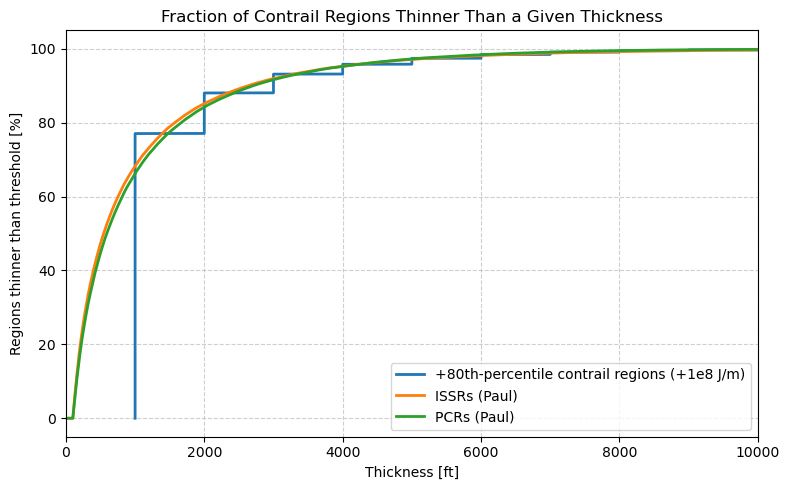

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Load and prepare data ---
file_path = "output/contrail_region_details_2024.csv"
df = pd.read_csv(file_path, parse_dates=["time"])

# Convert thickness from meters to feet
df["thickness_ft"] = df["thickness_m"] * 3.28084  # 1 m = 3.28084 ft

# Optional: filter out non-physical or missing values
df = df[df["thickness_ft"] > 0]

# --- Compute cumulative fraction (CDF) ---
thickness_sorted = np.sort(df["thickness_ft"].values)
fraction = np.arange(1, len(thickness_sorted) + 1) / len(thickness_sorted) * 100  # percent


df_paul = pd.read_csv("data\ISSR and PCR depth distribution.csv")
# --- Plot ---
plt.figure(figsize=(8, 5))
plt.plot(thickness_sorted, fraction, lw=2, label="+80th-percentile contrail regions (+1e8 J/m)")
plt.plot(df_paul["Thickness"], df_paul["Ice Super-Saturated Regions (ISSRs)"], lw=2, label="ISSRs (Paul)")
plt.plot(df_paul["Thickness"], df_paul["Persistent Contrail Regions (PCRs)"], lw=2, label="PCRs (Paul)")
plt.title("Fraction of Contrail Regions Thinner Than a Given Thickness")
plt.xlabel("Thickness [ft]")
plt.ylabel("Regions thinner than threshold [%]")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlim(0, 10_000)
plt.legend()
plt.tight_layout()
plt.show()
